# Baseline Bigram Language Model — Luffy GPT

This notebook implements a baseline bigram language model on the cleaned One Piece dialogue corpus.

Steps:
1. Load cleaned corpus + character tokenizer
2. Encode into a tensor
3. Visualize bigram frequencies
4. Build a data loader
5. Train a BigramLanguageModel (nn.Module)
6. Generate text — starting from a Luffy-style prompt
7. Visualize learned embedding table

In [1]:
# Load the cleaned, deduplicated corpus (output of preprocess_and_split.py)
with open("dataset/processed/corpus_clean.txt", "r") as f:
    text = f.read()

print(f"Corpus size : {len(text):,} chars")
print(f"Sample:")
print(text[:400])

Corpus size : 3,223,998 chars
Sample:
Gold Roger:
My treasure? If you want it, you can have it! Find it! I left everything this world has to offer there!

Marine 1:
Whoa...

Captain:
No worries! A whirlpool of that size poses no problem to this ship!

Man:
Miss. May I have this dance?

Marine 1:
Alright! Not again...

Marine 2:
Batter out!

Marine 3:
What're you doing? You suck!

Marine 1 + 2:
This thing's heavy! Must be filled with b


In [2]:
# Character-level vocabulary
characters = sorted(list(set(text)))
vocab_size  = len(characters)

char_to_idx = {ch: i for i, ch in enumerate(characters)}
idx_to_char = {i: ch for i, ch in enumerate(characters)}

encode = lambda xs: [char_to_idx[x] for x in xs]
decode = lambda xs: ''.join([idx_to_char[x] for x in xs])

print(f"Vocab size: {vocab_size}")

Vocab size: 96


In [3]:
import torch

data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:100])

torch.Size([3223998]) torch.int64
tensor([34, 69, 66, 58,  1, 45, 69, 61, 59, 72, 24,  0, 40, 79,  1, 74, 72, 59,
        55, 73, 75, 72, 59, 27,  1, 36, 60,  1, 79, 69, 75,  1, 77, 55, 68, 74,
         1, 63, 74, 11,  1, 79, 69, 75,  1, 57, 55, 68,  1, 62, 55, 76, 59,  1,
        63, 74,  2,  1, 33, 63, 68, 58,  1, 63, 74,  2,  1, 36,  1, 66, 59, 60,
        74,  1, 59, 76, 59, 72, 79, 74, 62, 63, 68, 61,  1, 74, 62, 63, 73,  1,
        77, 69, 72, 66, 58,  1, 62, 55, 73,  1])


## Dataset Analysis — Speaker Distribution

Unlike TinyShakespeare (which has dozens of named characters), our corpus has a small set of speaker labels. Most blocks are `Main:` (One Pace subtitle style). Episode 1 has real names: Luffy, Shanks, Koby, Alvida, etc.

In [4]:
from collections import Counter

blocks = [b.strip() for b in text.split("\n\n") if b.strip()]

speaker_counts = Counter()
for block in blocks:
    first_line = block.splitlines()[0]
    if first_line.endswith(":"):
        speaker_counts[first_line[:-1]] += 1

print(f"Total blocks: {len(blocks):,}")
print()
print("Speaker distribution:")
for speaker, count in speaker_counts.most_common():
    pct = count / len(blocks) * 100
    bar = '#' * int(pct / 2)
    print(f"  {speaker:<20} {count:>5}  ({pct:4.1f}%)  {bar}")

Total blocks: 5,171

Speaker distribution:
  Main                  2645  (51.2%)  #########################
  Thoughts              1041  (20.1%)  ##########
  Flashback              645  (12.5%)  ######
  Secondary              513  ( 9.9%)  ####
  Koby                    51  ( 1.0%)  
  Luffy                   48  ( 0.9%)  
  Alvida                  22  ( 0.4%)  
  Peppoko + Pirate 2       6  ( 0.1%)  
  Three-Sword Style        6  ( 0.1%)  
  Poppoko                  5  ( 0.1%)  
  Peppoko                  5  ( 0.1%)  
  Fishman Karate           4  ( 0.1%)  
  Two-Sword Style          4  ( 0.1%)  
  One-Sword Style          4  ( 0.1%)  
  Heppoko                  3  ( 0.1%)  
  Pirate 2                 3  ( 0.1%)  
  Okama Kenpo              3  ( 0.1%)  
  Diable Jambe             3  ( 0.1%)  
  Marine 1                 2  ( 0.0%)  
  Captain                  2  ( 0.0%)  
  Marine 3                 2  ( 0.0%)  
  Marine 1 + 2             2  ( 0.0%)  
  Pirate 4                 2  ( 

## Visualize Bigram Frequencies

What character pairs appear together most often? This reveals the dominant patterns in the corpus.

In [5]:
counts = {}
for ch1, ch2 in zip(data, data[1:]):
    bigram = (ch1.item(), ch2.item())
    counts[bigram] = counts.get(bigram, 0) + 1

decoded_counts = {decode(bigram): count for bigram, count in counts.items()}
top50 = sorted(decoded_counts.items(), key=lambda x: x[1], reverse=True)[:50]
print("Top 50 bigrams:")
for bigram, count in top50:
    print(f"  {repr(bigram):<10} {count:>8,}")

Top 50 bigrams:
  'e '         82,574
  ' t'         59,531
  '!\n'        55,618
  't '         52,362
  'th'         49,860
  'he'         47,134
  's '         45,940
  'ou'         42,416
  'in'         38,065
  ' a'         35,860
  're'         35,343
  '.\n'        34,634
  '..'         32,354
  'at'         31,024
  'er'         30,584
  ' s'         28,852
  'ha'         27,402
  'an'         26,559
  'd '         26,464
  ' w'         26,440
  'o '         25,031
  'on'         24,906
  ' i'         22,997
  'n '         22,492
  ', '         21,489
  ' o'         21,212
  ' h'         21,031
  'is'         20,742
  'y '         20,642
  'ng'         20,472
  'yo'         20,125
  'r '         19,631
  ' y'         19,407
  'to'         19,283
  'll'         19,041
  ' m'         18,553
  'ea'         18,540
  'hi'         18,382
  ' b'         17,868
  'ar'         17,425
  'it'         17,259
  'st'         17,035
  've'         17,005
  ' c'         16,985
  'or'         1

(np.float64(-0.5), np.float64(95.5), np.float64(95.5), np.float64(-0.5))

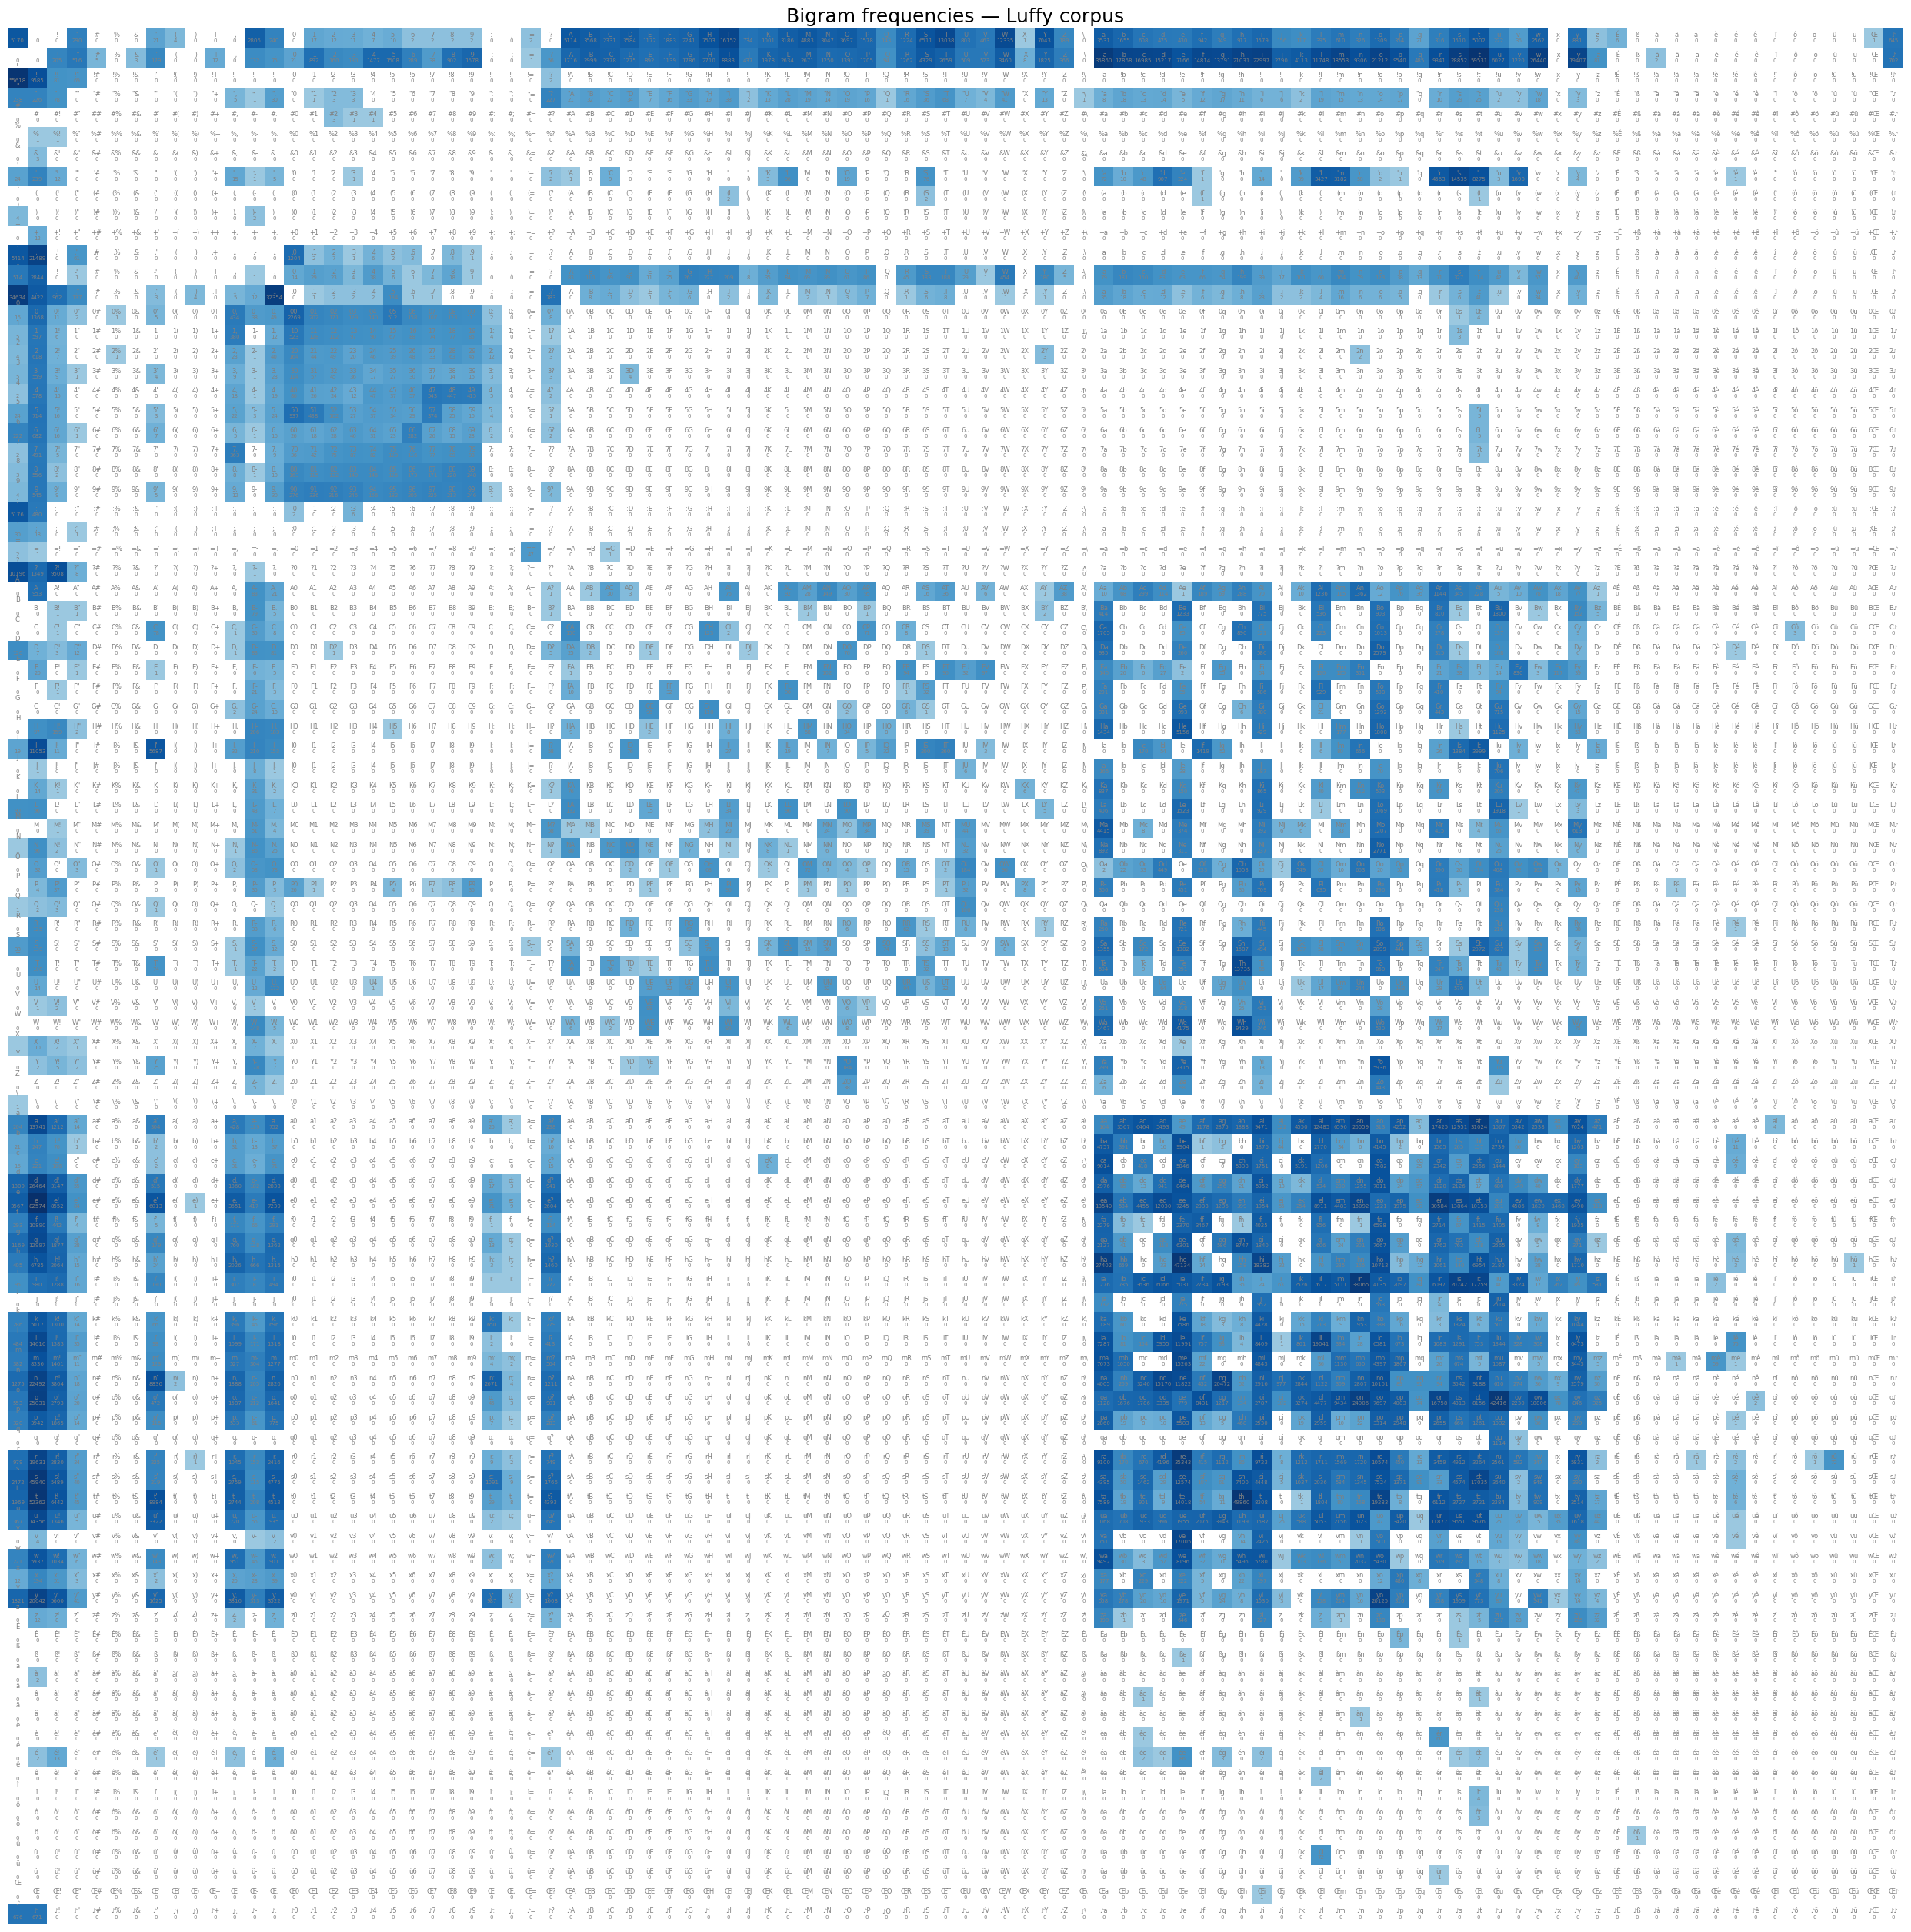

In [6]:
# The bigram heatmap — each cell (i,j) is how often char i is followed by char j
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

img = torch.zeros(vocab_size, vocab_size, dtype=torch.long)
for (i, j), count in counts.items():
    img[i, j] = count

plt.figure(figsize=(32, 32))
plt.imshow(img, cmap='Blues', norm=LogNorm(vmin=1e-3, vmax=img.max()))
for i in range(vocab_size):
    for j in range(vocab_size):
        chstr = decode([i, j])
        chstr = chstr.replace("$", "\$")  # escape matplotlib latex
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=6)
        plt.text(j, i, img[i, j].item(), ha="center", va="top", color='gray', fontsize=5)
plt.title("Bigram frequencies — Luffy corpus", fontsize=18)
plt.axis('off')

## Data Loader

Generator of pairs of inputs (X) and targets (Y)

- X — n-token sequence
- Y — the n tokens that follow X (shifted by 1)

For the bigram model n=1 (context_size=1 in spirit), but we pass context_size=8 to stay compatible with future transformer sessions.

In [7]:
# 90/10 split directly from the token stream (same as Kacper's baseline approach)
n = int(len(data) * 0.9)
train_data = data[:n]
val_data   = data[n:]
print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens  : {len(val_data):,}")

Train tokens: 2,901,598
Val tokens  : 322,400


In [8]:
context_size = 8
train_data[:context_size + 1]

tensor([34, 69, 66, 58,  1, 45, 69, 61, 59])

In [9]:
x = train_data[:context_size]
y = train_data[1:context_size + 1]
for t in range(context_size):
    context = x[:t + 1]
    target  = y[t]
    print(f"when input is {context.tolist()} -> {repr(decode(context.tolist()))!s:<20}  target: {target} ({repr(decode([target.item()]))})") 

when input is [34] -> 'G'                   target: 69 ('o')
when input is [34, 69] -> 'Go'                  target: 66 ('l')
when input is [34, 69, 66] -> 'Gol'                 target: 58 ('d')
when input is [34, 69, 66, 58] -> 'Gold'                target: 1 (' ')
when input is [34, 69, 66, 58, 1] -> 'Gold '               target: 45 ('R')
when input is [34, 69, 66, 58, 1, 45] -> 'Gold R'              target: 69 ('o')
when input is [34, 69, 66, 58, 1, 45, 69] -> 'Gold Ro'             target: 61 ('g')
when input is [34, 69, 66, 58, 1, 45, 69, 61] -> 'Gold Rog'            target: 59 ('e')


In [10]:
torch.manual_seed(1111)
batch_size   = 4   # independent sequences processed in parallel
context_size = 8   # max context length for predictions

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix   = torch.randint(len(data) - context_size, (batch_size,))
    x    = torch.stack([data[i:i + context_size]     for i in ix])
    y    = torch.stack([data[i + 1:i + context_size + 1] for i in ix])
    return x, y

In [11]:
xb, yb = get_batch('train')
print('inputs :', xb.shape)
print(xb)
print('---')
print('targets:', yb.shape)
print(yb)

inputs : torch.Size([4, 8])
tensor([[61,  7, 73,  1, 56, 55, 58,  1],
        [73, 74, 59, 55, 58,  2,  0, 40],
        [ 0, 50, 62, 55, 74,  1, 55,  1],
        [72, 69, 74, 62, 59, 72, 73,  1]])
---
targets: torch.Size([4, 8])
tensor([[ 7, 73,  1, 56, 55, 58,  1, 68],
        [74, 59, 55, 58,  2,  0, 40, 72],
        [50, 62, 55, 74,  1, 55,  1, 58],
        [69, 74, 62, 59, 72, 73,  1, 69]])


## Bigram Language Model

Torch implementation of a bigram generative model — essentially the learned version of the frequency table above.

`nn.Embedding(vocab_size, vocab_size)` stores one row per token: the logits for "what comes next given this token".

In [12]:
import torch
from torch import nn
import torch.nn.functional as F

In [13]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # lookup table: each token maps to a row of logits for the next token
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (batch_size, context_size)
        logits = self.token_embedding_table(idx)  # (B, T, C)

        if targets is not None:
            B, T, C = logits.shape
            logits  = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss    = F.cross_entropy(logits, targets)
        else:
            loss = None

        return logits, loss

In [14]:
def generate(model, start_idx, number_of_tokens):
    idx = start_idx
    for _ in range(number_of_tokens):
        logits, _ = model(idx)
        logits    = logits[:, -1, :]              # (B, C) — only last position
        probs     = F.softmax(logits, dim=-1)     # (B, C)
        idx_next  = torch.multinomial(probs, num_samples=1)  # (B, 1)
        idx       = torch.cat((idx, idx_next), dim=1)        # (B, T+1)
    return idx

In [15]:
m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print("logits shape:", logits.shape)
print("initial loss:", loss.item())
print(f"expected loss for random model: {-torch.log(torch.tensor(1/vocab_size)):.4f}  (= -log(1/{vocab_size}))")

logits shape: torch.Size([32, 96])
initial loss: 5.055430889129639
expected loss for random model: 4.5643  (= -log(1/96))


In [16]:
# Generate BEFORE training — expect gibberish
start_idx = torch.zeros((1, 1), dtype=torch.long)  # start token = char index 0
print("Before training:")
print(decode(generate(m, start_idx=start_idx, number_of_tokens=300)[0].tolist()))

Before training:

HZâ
Ét'h0DC4B9ß;is\6bdRôD,gEtlû?.E)üz:vGJWID27rFD.OjjîAê7\M%HK4fI,dCc-"..7aû%h8Mfê(
♪îh1E-V.K89HZhfvPB%#ô:m:F JN♪ècXrDTippps,àö7DŒmE&XdAmao%py ôuOznÉpp22Za;vdAOäS6ü-#;Sêà.YRèôhj6uŒe%OaäeBeyßéCwH%Zgm+cü,
ID&2b9Dqq=,àîÉ\"!
YgLnt"t"%%..,JOz3lQz1ppVOJâj%,Sql!RN5hDTpü=pXêbö
ü3êIâjRFWNîV ôxeu;5rüŒW# d8P%0


In [17]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [18]:
batch_size       = 32
report_frequency = 1000

for steps in range(10000):
    xb, yb = get_batch('train')

    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if steps % report_frequency == 0:
        # also check validation loss
        with torch.no_grad():
            xv, yv = get_batch('val')
            _, val_loss = m(xv, yv)
        print(f"Step {steps:>5}  train_loss={loss.item():.4f}  val_loss={val_loss.item():.4f}")

print(f"\nFinal train loss: {loss.item():.4f}")

Step     0  train_loss=5.0358  val_loss=4.9630
Step  1000  train_loss=3.9573  val_loss=3.9723
Step  2000  train_loss=3.3034  val_loss=3.2126
Step  3000  train_loss=2.9010  val_loss=2.9193
Step  4000  train_loss=2.6618  val_loss=2.7005
Step  5000  train_loss=2.6670  val_loss=2.5852
Step  6000  train_loss=2.5373  val_loss=2.4820
Step  7000  train_loss=2.3772  val_loss=2.4648
Step  8000  train_loss=2.6237  val_loss=2.5282
Step  9000  train_loss=2.5067  val_loss=2.5071

Final train loss: 2.4678


In [19]:
# Generate AFTER training — should look more like One Piece dialogue
# Start from a newline (like Kacper's approach with zero token)
start_idx = torch.zeros((1, 1), dtype=torch.long)
print("After training (from null start):")
print(decode(generate(m, start_idx=start_idx, number_of_tokens=300)[0].tolist()))

After training (from null start):

Inero bou, I tledst me con'sok
Themen theld t uin pt be g aror meru'tant?!
Kinounom-
Hocoushechicast oudy:
Do BeSu bants finavithetoitrouff ay, applliqup whe wê(6bes brt.
Ohahem?!
♪ŒWIthon rybeto't.twnm astrd ous haka Yoffoule Hou jowhit t s, s Int!
Wait!
Mar873;vestot y s th-Gul"!
TKipyo y knsutila


In [20]:
# Now start from an actual Luffy prompt — feed the model a context
prompt = "Luffy:\n"
prompt_tokens = torch.tensor([encode(prompt)], dtype=torch.long)
print(f"Prompt: {repr(prompt)}")
print()
print("Generated continuation:")
print(decode(generate(m, start_idx=prompt_tokens, number_of_tokens=300)[0].tolist()))

Prompt: 'Luffy:\n'

Generated continuation:
Luffy:

We d?
S
MURuf at ts the pe wat llok-s m a fer bun'm yedem th?
Brs n!
"éâ
Ozuthis m githar saisy mp dovederatourke ca o d as)Emy!
Istok
Th!
ig taco th-hiêOnono...
s ghabyosot pplita oteat.Ecovjincougeve! pig wh
YopiVRongerosind k clond, thoulllly us ive Lun t on, 97 alyere f t Mato n'maky nou't'sory


In [21]:
# Try with a Main: prompt (most common speaker in our corpus)
prompt = "Main:\n"
prompt_tokens = torch.tensor([encode(prompt)], dtype=torch.long)
print(f"Prompt: {repr(prompt)}")
print()
print("Generated continuation:")
print(decode(generate(m, start_idx=prompt_tokens, number_of_tokens=300)[0].tolist()))

Prompt: 'Main:\n'

Generated continuation:
Main:
If we ts fengat?
WherifandiPoufou,477whepwan!
Thadall!
B!
Se rourtrwal ow h avinginee! yone I 478N-nn.
Sanplime ?!
Thin innckeser ordere pnts we
CithacOh.
Bris............ey the ant wes...
I oro t'seany,0, Do!
Yai ounan d we h!
Zu! f We d
It lllld ano.

Shin!
Hast Pa atûyot!
fisirete erimeyos tuy!
W


## Visualize the Learned Embedding Table

Each row of `token_embedding_table.weight` is the learned logit distribution for that character.
Similar characters (like 'a' vs 'e' vs 'i') should have similar patterns after training.

(np.float64(-0.5), np.float64(95.5), np.float64(95.5), np.float64(-0.5))

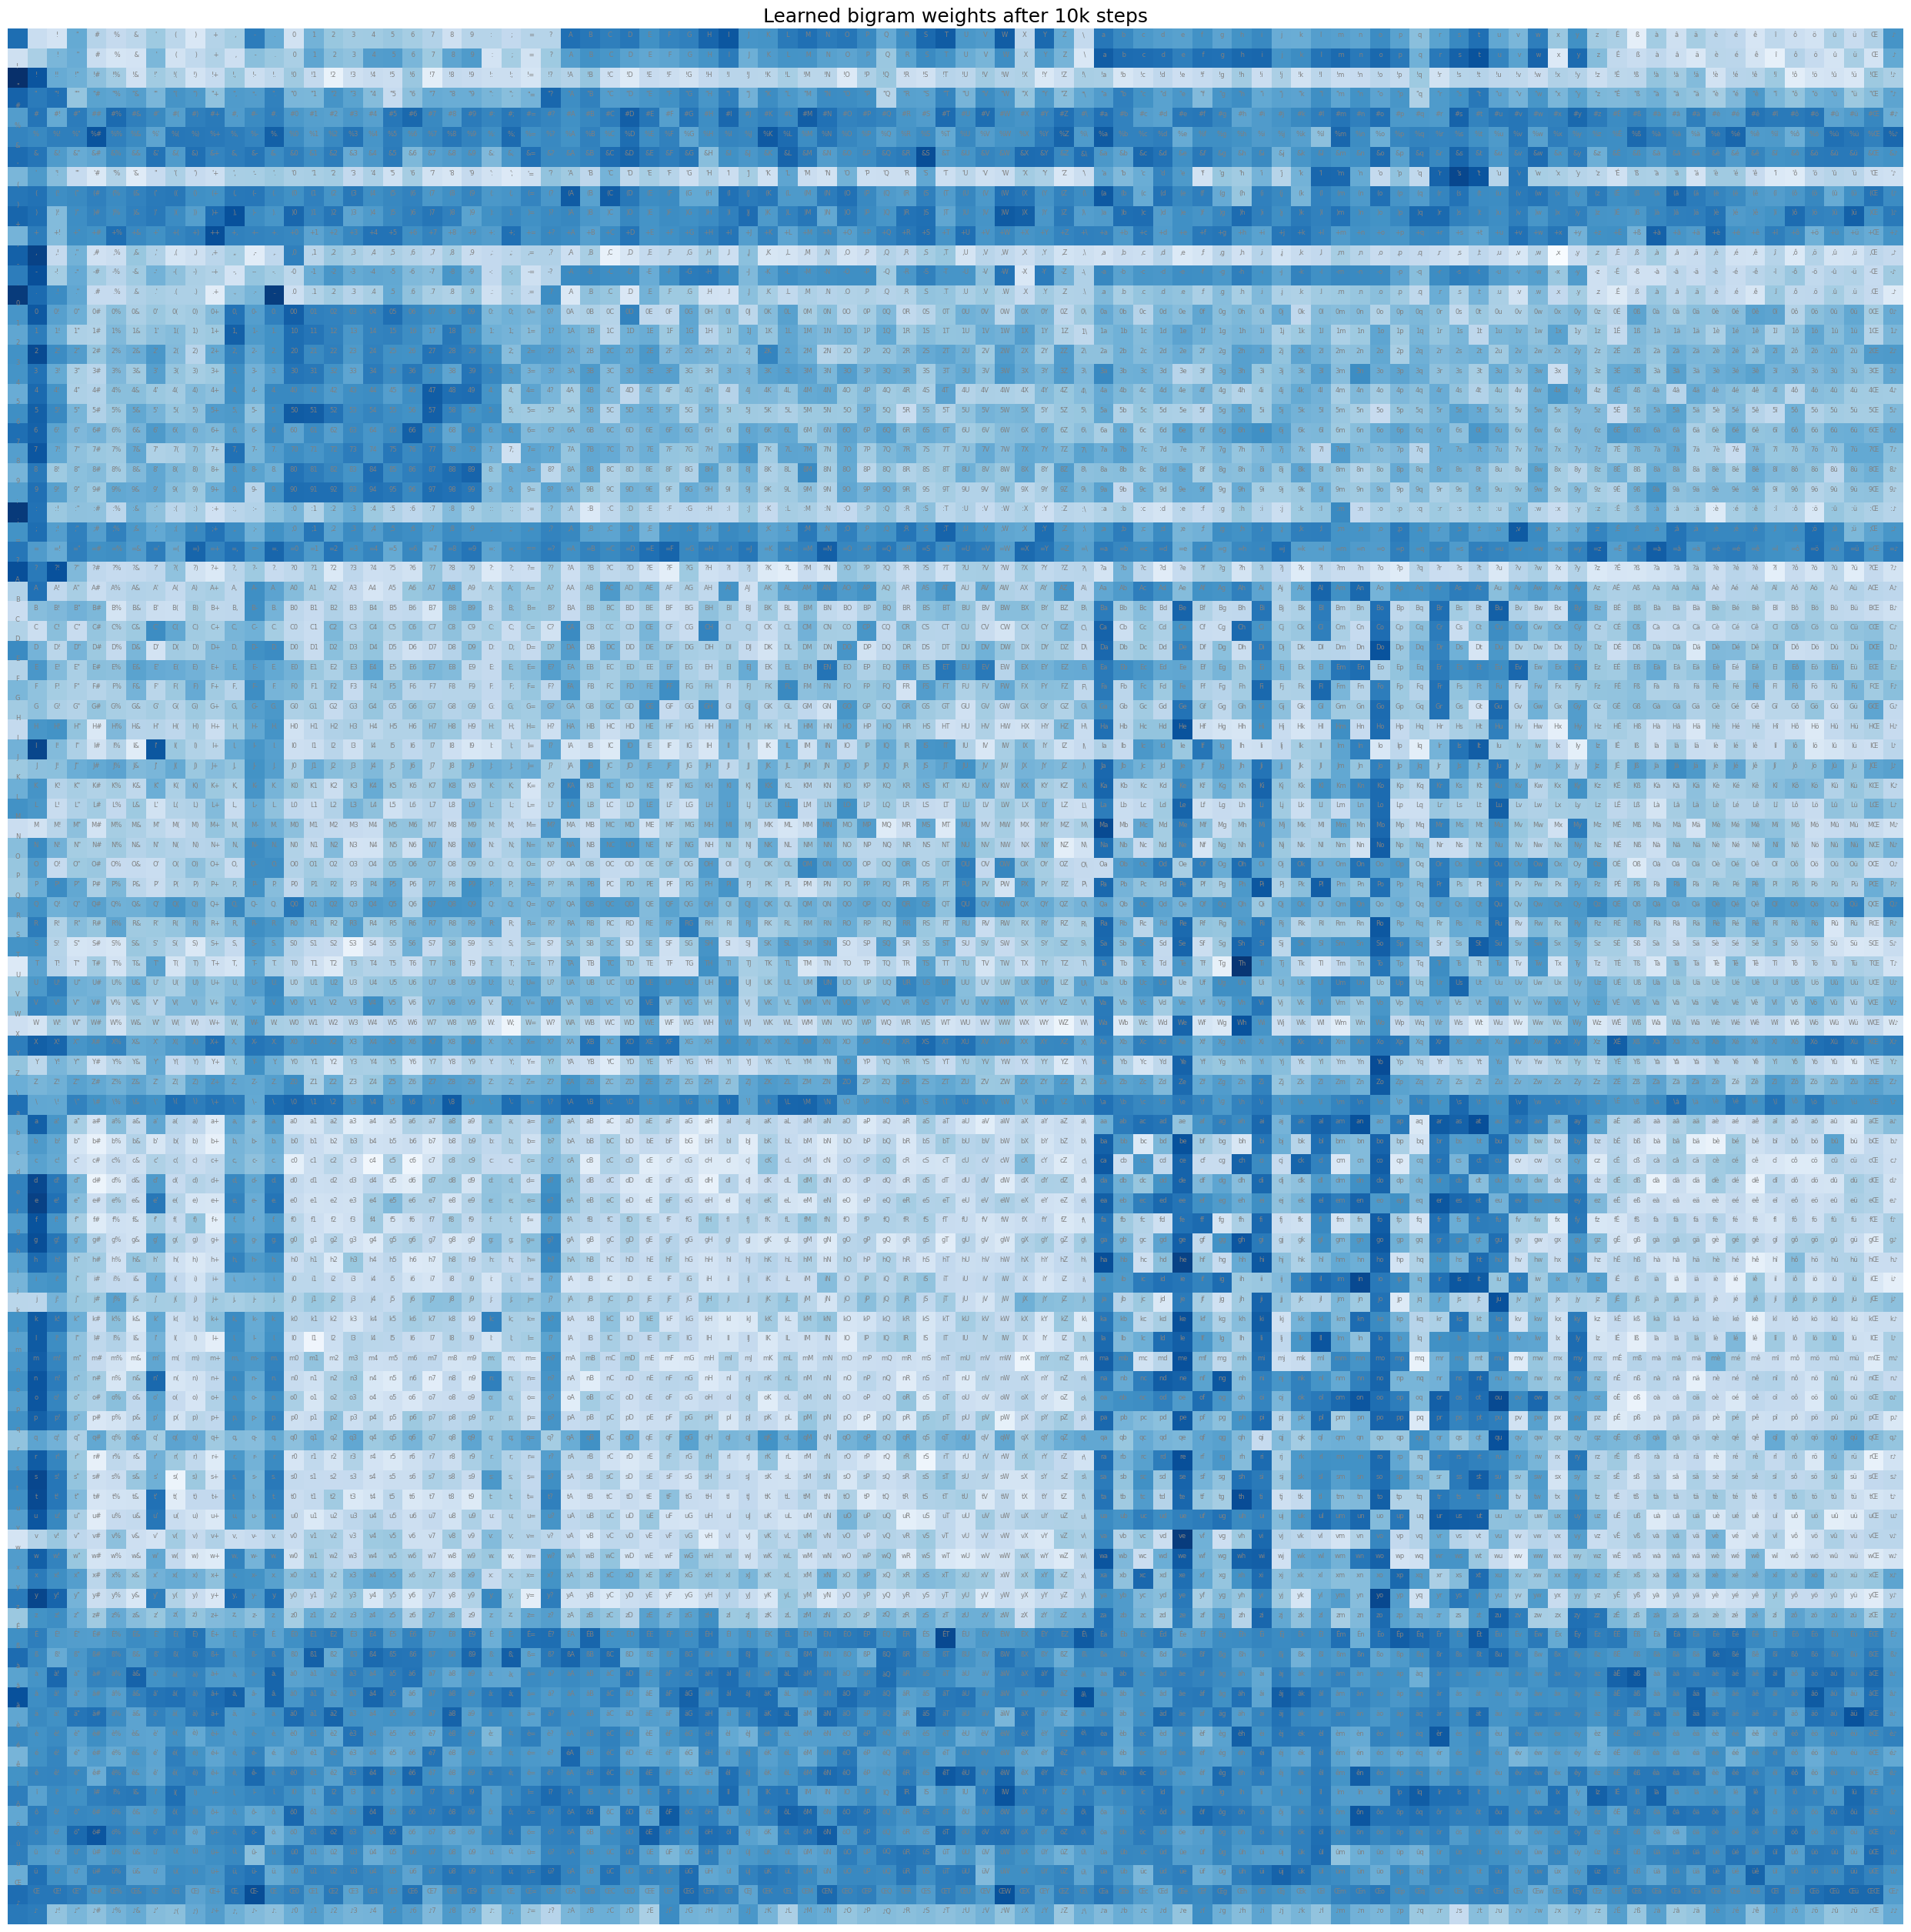

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

img = m.token_embedding_table.weight.detach().cpu().numpy()

plt.figure(figsize=(32, 32))
plt.imshow(img, cmap='Blues')
for i in range(vocab_size):
    for j in range(vocab_size):
        chstr = decode([i, j])
        chstr = chstr.replace("$", "\$")
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=6)
plt.title("Learned bigram weights after 10k steps", fontsize=18)
plt.axis('off')